In [1]:
# Surface wave dispersion data-model comparison
# Zachary Katz [Adapted from Samara Garvey]
# 18 January 2026

from disba import PhaseDispersion

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from obspy import read


def model():
    thick = [100, 2000, 120, 1000]
    vp = [3000, 3800, 2817, 5200]
    vs = [v/2 for v in vp] 
    rho = [500, 917, 2100, 3200]
    return thick, vp, vs, rho


def add_layer(rows,start_value,end_value,cols=1):
    # rows = thickness of layer (number of cells per layer)
    # start_value = starting value
    # end_value = endingvalue
    linear_values = np.linspace(start_value, end_value, rows)
    layer = np.tile(linear_values.reshape(-1, 1), (1, cols))
    return layer[::-1]


def generate(thick,vp,vs,rho):
    layers = [add_layer(thick[e], p, p) for e, p in enumerate(vp)]
    vp_out = np.vstack(layers)   
    
    layers = [add_layer(thick[e], s, s) for e, s in enumerate(vs)]
    vs_out = np.vstack(layers)   
    
    layers = [add_layer(thick[e], r, r) for e, r in enumerate(rho)]
    rho_out = np.vstack(layers)  
    
    thick_out = np.ones_like(vp_out[::-1]) # each cell is 1 m thick

    return thick_out[::-1], vp_out[::-1], vs_out[::-1], rho_out[::-1]
    


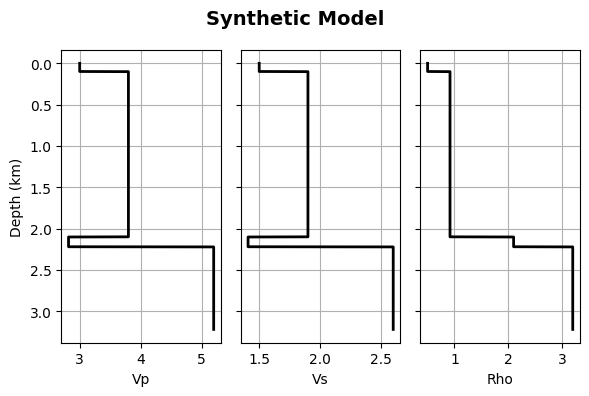

In [2]:
# CREATE SYNTHETIC MODEL #
thick, vp, vs, rho = model()
# Velocity model in format of: thickness, Vp, Vs, density (m, m/s, m/s, kg/m3)
THICK, VP, VS, RHO = generate(thick, vp, vs, rho)
velocity_model = np.column_stack((THICK/1000, VP/1000, VS/1000, RHO/1000))[::-1]
depths = np.cumsum(velocity_model[:,0])


fig, ax = plt.subplots(1, 3, figsize=(6, 4), sharey=True)
ax[0].plot(velocity_model[:, 1], depths, 'k', lw=2)
ax[0].set_xlabel('Vp')
ax[0].set_ylabel('Depth (km)')
ax[0].grid()
ax[0].invert_yaxis()
    

ax[1].plot(velocity_model[:, 2], depths, 'k', lw=2)
ax[1].set_xlabel('Vs')
ax[1].grid()
ax[2].plot(velocity_model[:, 3], depths, 'k', lw=2)
ax[2].set_xlabel('Rho')
ax[2].grid()
    
fig.suptitle('Synthetic Model', fontsize=14, fontweight='bold')
plt.tight_layout()

minfreq = 1
maxfreq = 200
numfreqs = 50

f_true = np.logspace(np.log10(minfreq), np.log10(maxfreq), numfreqs)[::-1]
periods = 1 / f_true

phase_disp = PhaseDispersion(*velocity_model.T, algorithm="fast-delta", dc=.001)


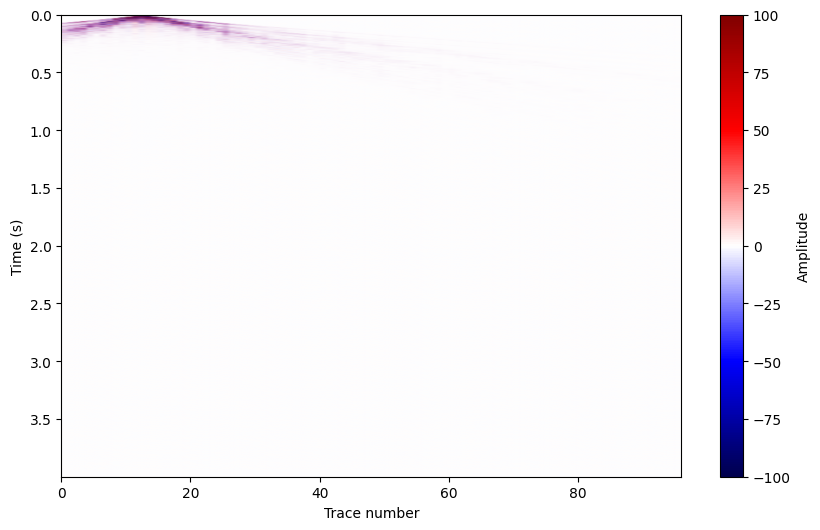

In [5]:
# Load observations and compute dispersion curve
sgy_file = '21YY_2'
sgy_path = sgy_file + '.sgy'
st = read(sgy_path, format="SEGY")
data = np.array([tr.data for tr in st]).T

dt = st[0].stats.delta  # sample interval (seconds)
nt, nx = data.shape

t = np.arange(nt) * dt

plt.figure(figsize=(10,6))
plt.imshow(data, aspect="auto", cmap="seismic",
           extent=[0, nx, t[-1], t[0]],vmin=-100,vmax=100)
plt.xlabel("Trace number")
plt.ylabel("Time (s)")
plt.colorbar(label="Amplitude")
plt.show()


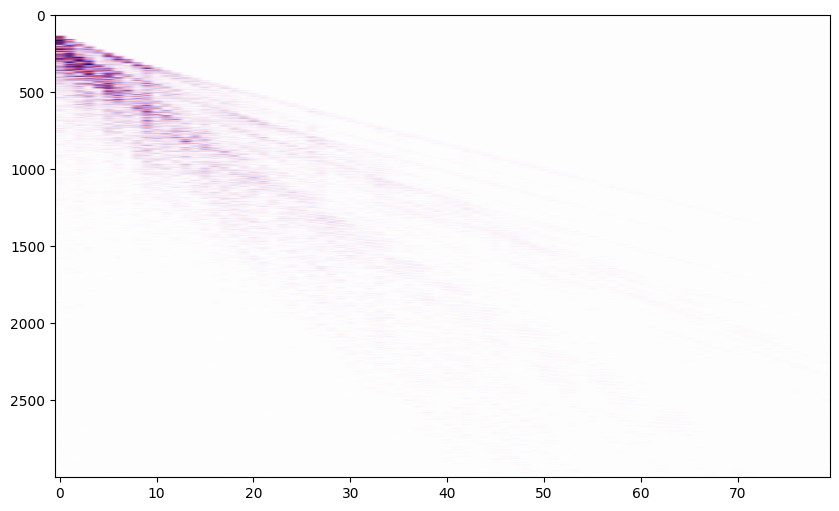

In [6]:
# Crop to one-sided gather
z = data
z = z[:3000, 16:] # One sided gather

dt = 0.00025  # seconds
trace_spacing = 15 # meters
off_min = 60  # minimum offset (trace_spacing * number of traces from center)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(z, aspect='auto', cmap='seismic',vmin=-100,vmax=100)

In [7]:
def fft_ephase(data):
    # Perform FFT along the time axis (rows)
    dfft = np.fft.fft(data, axis=0)
    # Extract the phase angle of the FFT result and construct the complex exponential of the phase term
    phase = np.angle(dfft) 
    e_phase = np.exp(-1j * phase)

    # OR just normalize the FFT to get the complex exponential of the phase term
    e_phase = dfft / (np.abs(dfft))
    return dfft, phase, e_phase


def test_ephase(receiver_offset, F, C):
    # Compute phase shift in radians: (2πf/velocity) * offset) or (omega * offset)
    phase_t = (2 * np.pi * F ) / C

    # Compute complex exponential of the phase term (IF USING normalization to get e_phase)
    e_phase_t = np.power(np.exp(1j * phase_t),receiver_offset)

    # Compute complex exponential of the phase term (IF USING np.phase angle to get e_phase)
    # e_phase_t = np.power(np.exp(-1j * phase_t),receiver_offset)

    return phase_t, e_phase_t

data = z

no_samples, no_traces = data.shape
offsets = np.arange(off_min, off_min + trace_spacing * no_traces, trace_spacing)

###########################################################################################
print("FFT")
dfft, ph, eph = fft_ephase(data)
freq = np.fft.fftfreq(no_samples, d=dt)

# Apply fftshift so freq runs from negative → positive
dfft_all = np.fft.fftshift(dfft, axes=0)
ph_all = np.fft.fftshift(ph, axes=0)
eph_all = np.fft.fftshift(eph, axes=0)
freq_all = np.fft.fftshift(freq)

###########################################################################################
print("Mesh")
c_step = 1
c_start = 800
c_end = 2800
c_range = np.arange(c_start, c_end + c_step , c_step)  # Test range for velocities --- you may need to adjust this
F, C = np.meshgrid(freq_all, c_range)

###########################################################################################
print("Stack")
dp={}
for e, o in enumerate(offsets[:]):
    print(f"Offset {e}, {o}")
    ph_t, eph_t = test_ephase(o,F,C)
    dp[e] = eph_all[:,e] * eph_t

stack = sum(dp[key] for key in dp)
A = (np.abs( stack / len(dp) ))

FFT
Mesh
Stack
Offset 0, 60
Offset 1, 75
Offset 2, 90
Offset 3, 105
Offset 4, 120
Offset 5, 135
Offset 6, 150
Offset 7, 165
Offset 8, 180
Offset 9, 195
Offset 10, 210
Offset 11, 225
Offset 12, 240
Offset 13, 255
Offset 14, 270
Offset 15, 285
Offset 16, 300
Offset 17, 315
Offset 18, 330
Offset 19, 345
Offset 20, 360
Offset 21, 375
Offset 22, 390
Offset 23, 405
Offset 24, 420
Offset 25, 435
Offset 26, 450
Offset 27, 465
Offset 28, 480
Offset 29, 495
Offset 30, 510
Offset 31, 525
Offset 32, 540
Offset 33, 555
Offset 34, 570
Offset 35, 585
Offset 36, 600
Offset 37, 615
Offset 38, 630
Offset 39, 645
Offset 40, 660
Offset 41, 675
Offset 42, 690
Offset 43, 705
Offset 44, 720
Offset 45, 735
Offset 46, 750
Offset 47, 765
Offset 48, 780
Offset 49, 795
Offset 50, 810
Offset 51, 825
Offset 52, 840
Offset 53, 855
Offset 54, 870
Offset 55, 885
Offset 56, 900
Offset 57, 915
Offset 58, 930
Offset 59, 945
Offset 60, 960
Offset 61, 975
Offset 62, 990
Offset 63, 1005
Offset 64, 1020
Offset 65, 1035
Offse

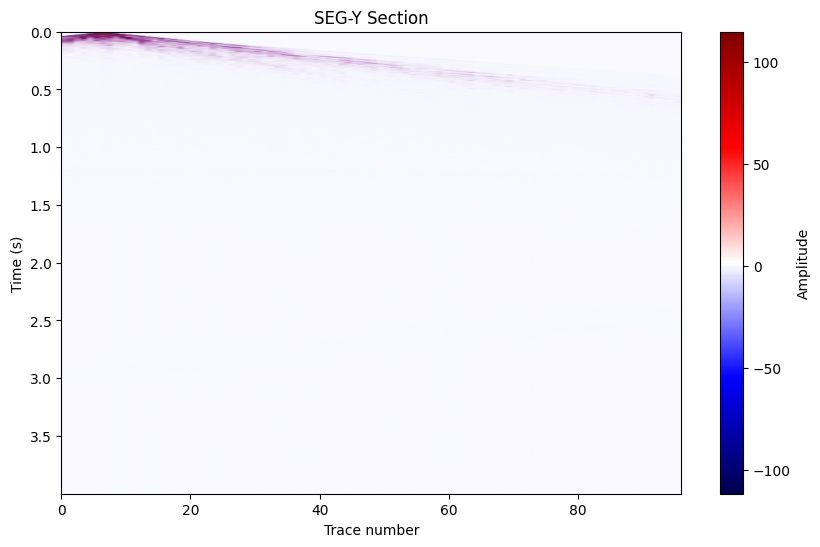

In [8]:
############
line = '21Y'
geometry_path = f'./_data/KPDC_David_Seismic_2022/RAW/{line}-Geometry.csv' 
sgy_file = f'./_data/KPDC_David_Seismic_2022/RAW/{line}'
num_shots = 20 # Number of shots on this Line [X=56, Y=40, XX=28. YY=20]
############

sgy_path = sgy_file + '.sgy'

# Load segy
st = read(sgy_path, format="SEGY")
trace_chosen = 9
tracenum=96
data = np.array([tr.data for tr in st[trace_chosen*tracenum:(1+trace_chosen)*tracenum]]).T

dt = st[0].stats.delta  # sample interval (seconds)
nt, nx = data.shape

t = np.arange(nt) * dt

plt.figure(figsize=(10,6))
plt.imshow(data, aspect="auto", cmap="seismic",
           extent=[0, nx, t[-1], t[0]])
plt.xlabel("Trace number")
plt.ylabel("Time (s)")
plt.title("SEG-Y Section")
plt.colorbar(label="Amplitude")
plt.show()


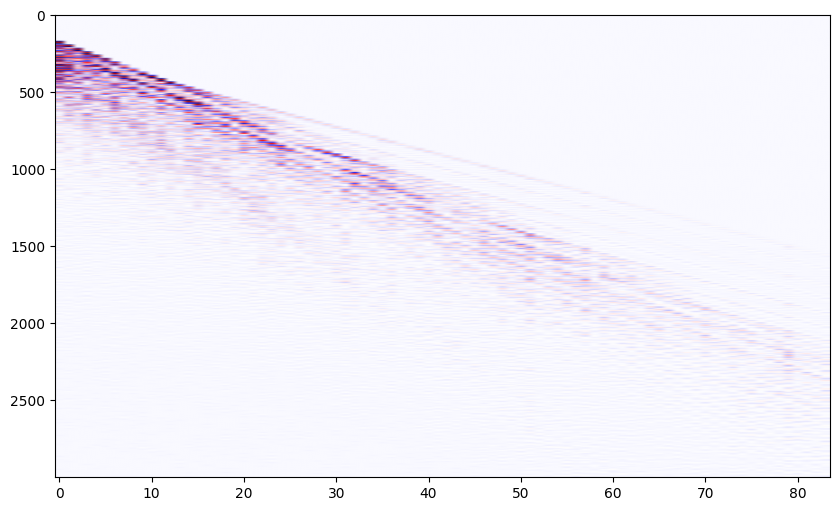

In [9]:
z = data
### CHANGE HERE TO ENSURE ONE SIDED GATHER
z = z[:3000, 12:] # One sided gather

dt = 0.00025  # seconds
trace_spacing = 15 # meters
off_min = 90  # minimum offset of your data

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(z, aspect='auto', cmap='seismic')

In [12]:

data = z # np.fliplr(z) # flip if negative offsets


no_samples, no_traces = data.shape
offsets = np.arange(off_min, off_min + trace_spacing * no_traces, trace_spacing)

###########################################################################################
print("FFT")
dfft, ph, eph = fft_ephase(data)
freq = np.fft.fftfreq(no_samples, d=dt)

# Apply fftshift so freq runs from negative → positive
dfft_all = np.fft.fftshift(dfft, axes=0)
ph_all = np.fft.fftshift(ph, axes=0)
eph_all = np.fft.fftshift(eph, axes=0)
freq_all = np.fft.fftshift(freq)

###########################################################################################
print("Mesh")
c_step = 1
c_range = np.arange(800, 2800 + c_step , c_step)  # Test range for velocities --- you may need to adjust this
F_prime, C_prime = np.meshgrid(freq_all, c_range)

###########################################################################################
print("Stack")
dp={}
for e, o in enumerate(offsets[:]):
    print(f"Offset {e}, {o}")
    ph_t, eph_t = test_ephase(o,F,C)
    dp[e] = eph_all[:,e] * eph_t

stack = sum(dp[key] for key in dp)
A_prime = (np.abs( stack / len(dp) ))

FFT
Mesh
Stack
Offset 0, 90
Offset 1, 105
Offset 2, 120
Offset 3, 135
Offset 4, 150
Offset 5, 165
Offset 6, 180
Offset 7, 195
Offset 8, 210
Offset 9, 225
Offset 10, 240
Offset 11, 255
Offset 12, 270
Offset 13, 285
Offset 14, 300
Offset 15, 315
Offset 16, 330
Offset 17, 345
Offset 18, 360
Offset 19, 375
Offset 20, 390
Offset 21, 405
Offset 22, 420
Offset 23, 435
Offset 24, 450
Offset 25, 465
Offset 26, 480
Offset 27, 495
Offset 28, 510
Offset 29, 525
Offset 30, 540
Offset 31, 555
Offset 32, 570
Offset 33, 585
Offset 34, 600
Offset 35, 615
Offset 36, 630
Offset 37, 645
Offset 38, 660
Offset 39, 675
Offset 40, 690
Offset 41, 705
Offset 42, 720
Offset 43, 735
Offset 44, 750
Offset 45, 765
Offset 46, 780
Offset 47, 795
Offset 48, 810
Offset 49, 825
Offset 50, 840
Offset 51, 855
Offset 52, 870
Offset 53, 885
Offset 54, 900
Offset 55, 915
Offset 56, 930
Offset 57, 945
Offset 58, 960
Offset 59, 975
Offset 60, 990
Offset 61, 1005
Offset 62, 1020
Offset 63, 1035
Offset 64, 1050
Offset 65, 1065
O

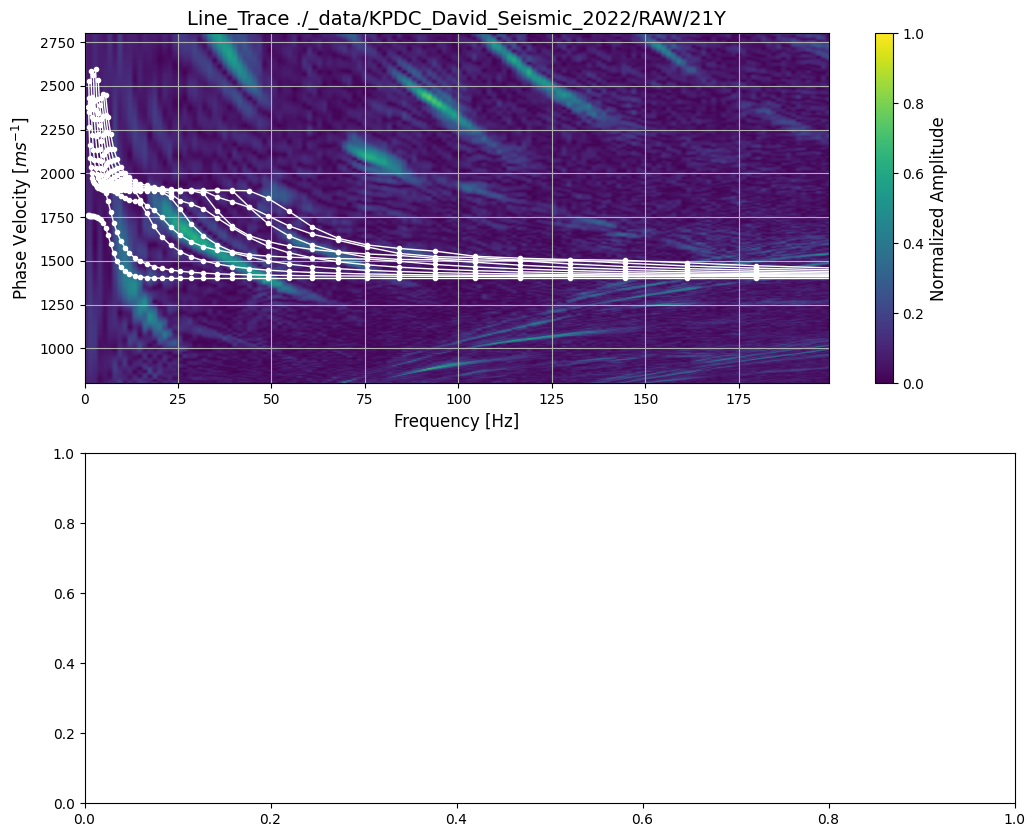

In [ ]:
# Plot data dispersion panel and modeled curves
fig, (ax,ax2) = plt.subplots(2,1, figsize=(12, 10))
cp = ax.imshow(
    A,
    extent=[F.min(), F.max(), C.min(), C.max()],
    origin='lower',
    aspect='auto',
    cmap='viridis',
    vmin=0,
    vmax=1
)
cb = fig.colorbar(cp)
cb.set_label('Normalized Amplitude', fontsize=12)
ax.set_xlabel('Frequency [Hz]', fontsize=12)
ax.set_ylabel('Phase Velocity [$m s^{-1}$]', fontsize=12)
ax.set_title(f"Line_Trace 21YY_2", fontsize=14)
ax.set_xlim(0,199)
ax.set_ylim(c_start,c_end)
ax.grid()

for m in range(0, 10):
    d_disba = phase_disp(periods, mode=m, wave="rayleigh")
    ax.plot(1/d_disba.period, (d_disba.velocity)*1000, '.-', linewidth=1, label=f'Mode {m}',color='white')


fig.savefig(f"Ex_DispersionPanel.png", dpi=300)

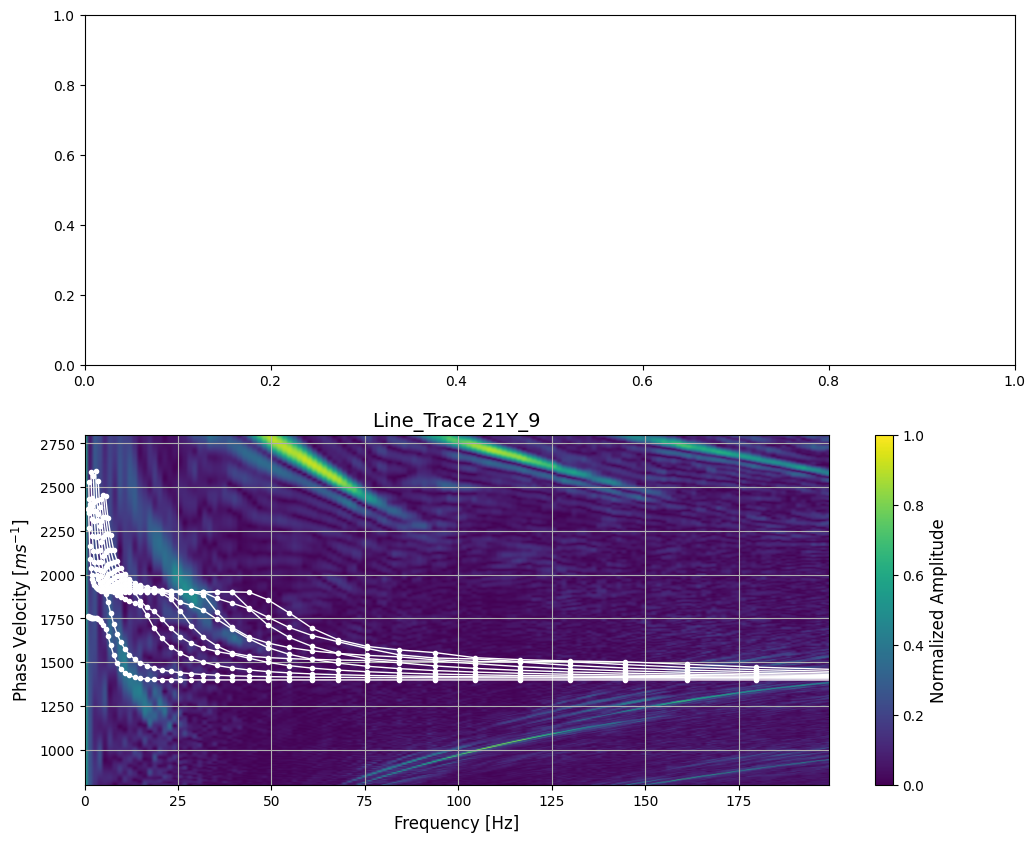

In [13]:
# Plot data dispersion panel and modeled curves
fig, (ax,ax2) = plt.subplots(2,1, figsize=(12, 10))
cp2 = ax2.imshow(
    A_prime,
    extent=[F.min(), F.max(), C.min(), C.max()],
    origin='lower',
    aspect='auto',
    cmap='viridis',
    vmin=0,
    vmax=1
)
cb = fig.colorbar(cp2)
cb.set_label('Normalized Amplitude', fontsize=12)
ax2.set_xlabel('Frequency [Hz]', fontsize=12)
ax2.set_ylabel('Phase Velocity [$m s^{-1}$]', fontsize=12)
ax2.set_title(f"Line_Trace 21Y_9", fontsize=14)
ax2.set_xlim(0,199)
ax2.set_ylim(c_start,c_end)
ax2.grid()

for m in range(0, 10):
    d_disba = phase_disp(periods, mode=m, wave="rayleigh")
    ax2.plot(1/d_disba.period, (d_disba.velocity)*1000, '.-', linewidth=1, label=f'Mode {m}',color='white')

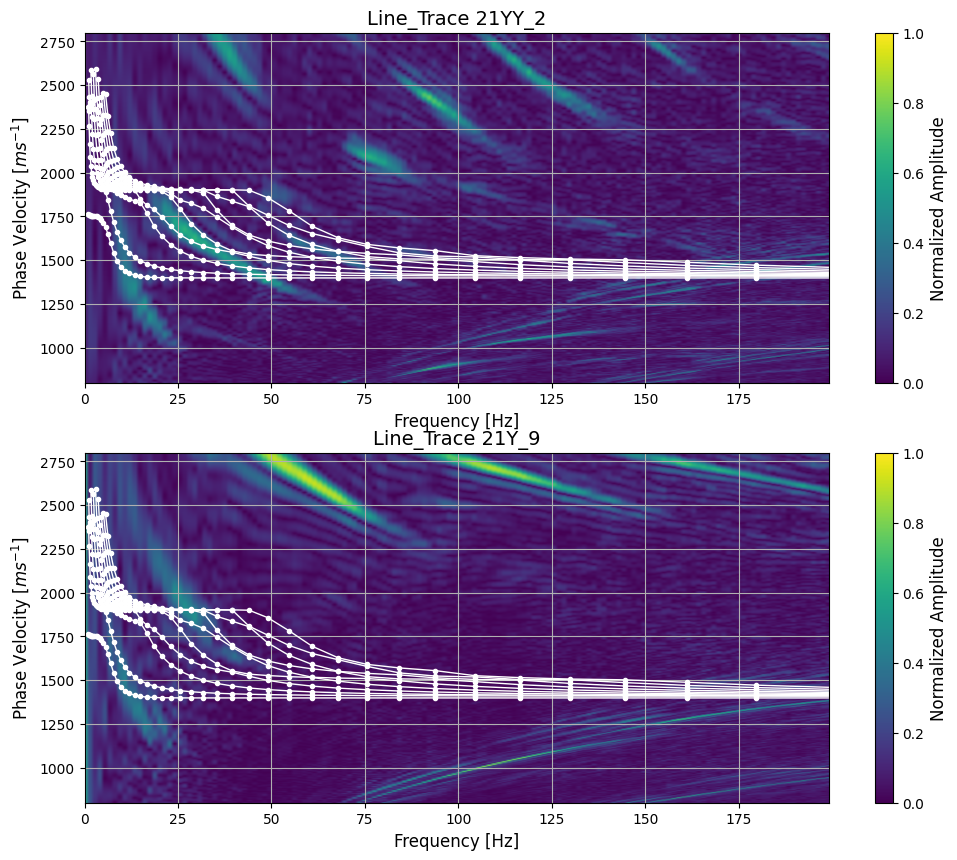

In [14]:
# Combine into one plot
# Plot data dispersion panel and modeled curves
fig, (ax,ax2) = plt.subplots(2,1, figsize=(12, 10))


cp = ax.imshow(
    A,
    extent=[F.min(), F.max(), C.min(), C.max()],
    origin='lower',
    aspect='auto',
    cmap='viridis',
    vmin=0,
    vmax=1
)
cb = fig.colorbar(cp)
cb.set_label('Normalized Amplitude', fontsize=12)
ax.set_xlabel('Frequency [Hz]', fontsize=12)
ax.set_ylabel('Phase Velocity [$m s^{-1}$]', fontsize=12)
ax.set_title(f"Line_Trace 21YY_2", fontsize=14)
ax.set_xlim(0,199)
ax.set_ylim(c_start,c_end)
ax.grid()

for m in range(0, 10):
    d_disba = phase_disp(periods, mode=m, wave="rayleigh")
    ax.plot(1/d_disba.period, (d_disba.velocity)*1000, '.-', linewidth=1, label=f'Mode {m}',color='white')

cp2 = ax2.imshow(
    A_prime,
    extent=[F.min(), F.max(), C.min(), C.max()],
    origin='lower',
    aspect='auto',
    cmap='viridis',
    vmin=0,
    vmax=1
)
cb = fig.colorbar(cp2)
cb.set_label('Normalized Amplitude', fontsize=12)
ax2.set_xlabel('Frequency [Hz]', fontsize=12)
ax2.set_ylabel('Phase Velocity [$m s^{-1}$]', fontsize=12)
ax2.set_title(f"Line_Trace 21Y_9", fontsize=14)
ax2.set_xlim(0,199)
ax2.set_ylim(c_start,c_end)
ax2.grid()

for m in range(0, 10):
    d_disba = phase_disp(periods, mode=m, wave="rayleigh")
    ax2.plot(1/d_disba.period, (d_disba.velocity)*1000, '.-', linewidth=1, label=f'Mode {m}',color='white')


fig.savefig(f"Ex_DispersionPanel.png", dpi=300)